In [ ]:
!pip install pandapower matplotlib seaborn numpy pandas -q

In [ ]:
import pandapower as pp
import pandapower.networks as pn
import pandapower.plotting as plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f'pandapower version: {pp.__version__}')
print('All imports successful.')

pandapower version: 3.4.0
All imports successful.


In [ ]:
net = pn.case39()

print('=== IEEE 39-Bus System Loaded ===')
print(f'Buses         : {len(net.bus)}')
print(f'Lines         : {len(net.line)}')
print(f'Transformers  : {len(net.trafo)}')
print(f'Generators    : {len(net.gen)}')
print(f'Loads         : {len(net.load)}')
print(f'External grids: {len(net.ext_grid)}')

=== IEEE 39-Bus System Loaded ===
Buses         : 39
Lines         : 35
Transformers  : 11
Generators    : 9
Loads         : 21
External grids: 1


In [ ]:
print('--- BUS TABLE (first 10) ---')
print(net.bus.head(10))

print('\n--- LOAD TABLE ---')
print(net.load[['bus', 'p_mw', 'q_mvar']].to_string())

print('\n--- GENERATOR TABLE ---')
print(net.gen[['bus', 'p_mw', 'vm_pu']].to_string())

--- BUS TABLE (first 10) ---
  name  vn_kv type zone  in_service  max_vm_pu  min_vm_pu  \
0    1  345.0    b  2.0        True       1.06       0.94   
1    2  345.0    b  2.0        True       1.06       0.94   
2    3  345.0    b  2.0        True       1.06       0.94   
3    4  345.0    b  1.0        True       1.06       0.94   
4    5  345.0    b  1.0        True       1.06       0.94   
5    6  345.0    b  1.0        True       1.06       0.94   
6    7  345.0    b  1.0        True       1.06       0.94   
7    8  345.0    b  1.0        True       1.06       0.94   
8    9  345.0    b  1.0        True       1.06       0.94   
9   10  345.0    b  1.0        True       1.06       0.94   

                                                 geo  
0  {"coordinates": [3.8651896006, -7.5205436056],...  
1  {"coordinates": [2.781130914, -6.995664623], "...  
2  {"coordinates": [2.8004813789, -5.7410613533],...  
3  {"coordinates": [3.5065013264, -4.7551145087],...  
4  {"coordinates": [4.74

In [ ]:
pp.runpp(net, algorithm='nr', calculate_voltage_angles=True)

print('Power flow converged successfully.')
print(f'\nConverged: {net.converged}')

print('\n--- RESULTS: Voltage at each bus ---')
results = net.res_bus[['vm_pu', 'va_degree']].copy()
results.index.name = 'bus_id'
results.columns = ['Voltage Magnitude (pu)', 'Voltage Angle (deg)']
print(results.to_string())

Power flow converged successfully.

Converged: True

--- RESULTS: Voltage at each bus ---
        Voltage Magnitude (pu)  Voltage Angle (deg)
bus_id                                             
0                     1.039384           -13.536602
1                     1.048494            -9.785267
2                     1.030708           -12.276384
3                     1.004460           -12.626734
4                     1.006006           -11.192339
5                     1.008226           -10.408330
6                     0.998397           -12.755626
7                     0.997872           -13.335844
8                     1.038332           -14.178442
9                     1.017843            -8.170875
10                    1.013386            -8.936966
11                    1.000815            -8.998824
12                    1.014923            -8.929927
13                    1.012319           -10.715295
14                    1.016185           -11.345399
15                    1.03

In [ ]:
vm = net.res_bus['vm_pu']

print('=== Voltage Summary ===')
print(f'Min voltage  : {vm.min():.4f} pu  (Bus {vm.idxmin()})')
print(f'Max voltage  : {vm.max():.4f} pu  (Bus {vm.idxmax()})')
print(f'Mean voltage : {vm.mean():.4f} pu')
print(f'Std deviation: {vm.std():.4f} pu')

# Classify buses
normal   = (vm >= 0.95) & (vm <= 1.05)
warning  = ((vm >= 0.90) & (vm < 0.95)) | ((vm > 1.05) & (vm <= 1.10))
critical = (vm < 0.90) | (vm > 1.10)

print(f'\nBuses in normal range   (0.95-1.05 pu): {normal.sum()}')
print(f'Buses in warning range  (0.90-0.95 pu): {warning.sum()}')
print(f'Buses in critical range (<0.90 pu)    : {critical.sum()}')

=== Voltage Summary ===
Min voltage  : 0.9820 pu  (Bus 30)
Max voltage  : 1.0636 pu  (Bus 35)
Mean voltage : 1.0263 pu
Std deviation: 0.0219 pu

Buses in normal range   (0.95-1.05 pu): 32
Buses in warning range  (0.90-0.95 pu): 7
Buses in critical range (<0.90 pu)    : 0


Bus 30 is the most voltage-sensitive bus in the IEEE 39-bus system — not because of heavy load, but because of poor reactive power support due to distance from generators. It will be the first bus to collapse as system stress increases.

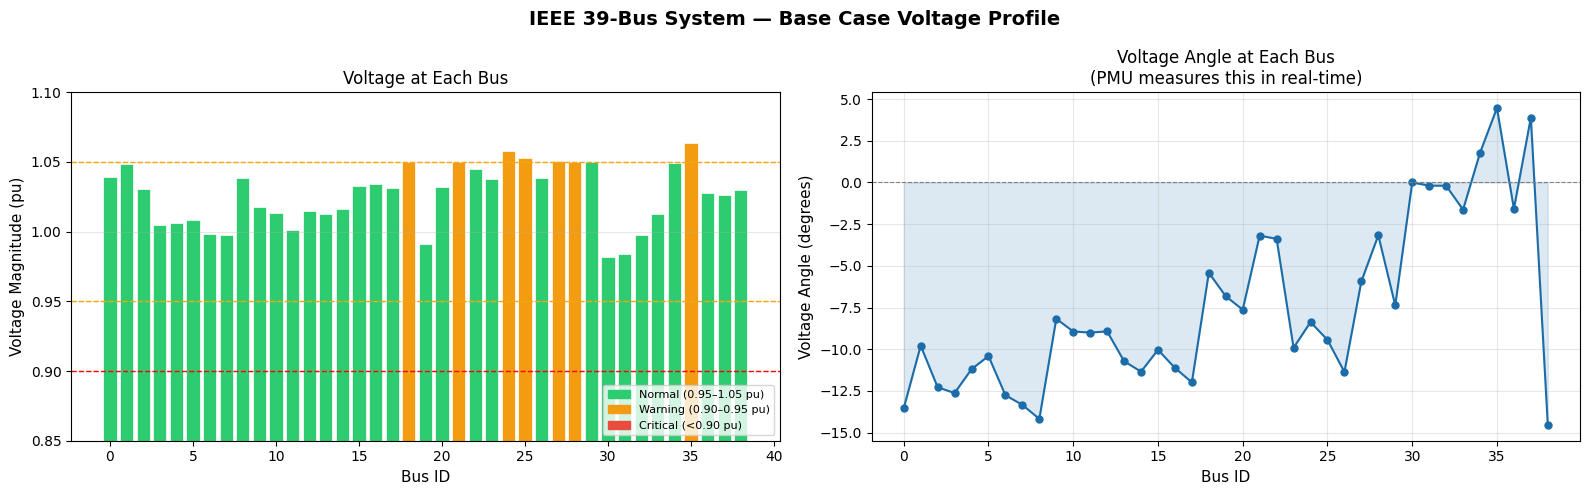

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('IEEE 39-Bus System — Base Case Voltage Profile', fontsize=14, fontweight='bold')

ax1 = axes[0]
bus_ids = net.res_bus.index
voltages = net.res_bus['vm_pu'].values

colors_bar = []
for v in voltages:
    if v < 0.90 or v > 1.10:
        colors_bar.append('#e74c3c')   # red: critical
    elif v < 0.95 or v > 1.05:
        colors_bar.append('#f39c12')   # orange: warning
    else:
        colors_bar.append('#2ecc71')   # green: normal

bars = ax1.bar(bus_ids, voltages, color=colors_bar, edgecolor='white', linewidth=0.5)
ax1.axhline(y=1.05, color='orange', linestyle='--', linewidth=1, label='Upper limit (1.05 pu)')
ax1.axhline(y=0.95, color='orange', linestyle='--', linewidth=1, label='Lower limit (0.95 pu)')
ax1.axhline(y=0.90, color='red',    linestyle='--', linewidth=1, label='Critical limit (0.90 pu)')
ax1.set_xlabel('Bus ID', fontsize=11)
ax1.set_ylabel('Voltage Magnitude (pu)', fontsize=11)
ax1.set_title('Voltage at Each Bus', fontsize=12)
ax1.set_ylim(0.85, 1.10)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Legend patches
patches = [
    mpatches.Patch(color='#2ecc71', label='Normal (0.95–1.05 pu)'),
    mpatches.Patch(color='#f39c12', label='Warning (0.90–0.95 pu)'),
    mpatches.Patch(color='#e74c3c', label='Critical (<0.90 pu)'),
]
ax1.legend(handles=patches, fontsize=8, loc='lower right')


ax2 = axes[1]
angles = net.res_bus['va_degree'].values
ax2.plot(bus_ids, angles, 'o-', color='#1B6CA8', linewidth=1.5, markersize=5)
ax2.fill_between(bus_ids, angles, alpha=0.15, color='#1B6CA8')
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Bus ID', fontsize=11)
ax2.set_ylabel('Voltage Angle (degrees)', fontsize=11)
ax2.set_title('Voltage Angle at Each Bus\n(PMU measures this in real-time)', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('base_case_voltage_profile.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Store base load values
base_p = net.load['p_mw'].values.copy()
base_q = net.load['q_mvar'].values.copy()

load_factors = np.arange(0.5, 2.05, 0.05)  # 50% to 200% in 5% steps
min_voltages = []
mean_voltages = []
converged_flags = []

for lf in load_factors:
    # Reset network to base case
    net_temp = pn.case39()
    net_temp.load['p_mw'] = base_p * lf
    net_temp.load['q_mvar'] = base_q * lf

    try:
        pp.runpp(net_temp, algorithm='nr', calculate_voltage_angles=True, max_iteration=50)
        if net_temp.converged:
            min_voltages.append(net_temp.res_bus['vm_pu'].min())
            mean_voltages.append(net_temp.res_bus['vm_pu'].mean())
            converged_flags.append(True)
        else:
            min_voltages.append(np.nan)
            mean_voltages.append(np.nan)
            converged_flags.append(False)
    except:
        min_voltages.append(np.nan)
        mean_voltages.append(np.nan)
        converged_flags.append(False)

# Build results DataFrame
pv_df = pd.DataFrame({
    'load_factor': load_factors,
    'load_pct': load_factors * 100,
    'min_voltage': min_voltages,
    'mean_voltage': mean_voltages,
    'converged': converged_flags
})

print(pv_df.to_string(index=False))
print(f"\nSystem diverges (collapse) beyond {pv_df[pv_df['converged']]['load_pct'].max():.0f}% load")

 load_factor  load_pct  min_voltage  mean_voltage  converged
        0.50      50.0     0.772688      0.951400       True
        0.55      55.0     0.880504      0.985804       True
        0.60      60.0     0.927073      1.001293       True
        0.65      65.0     0.956525      1.011505       True
        0.70      70.0     0.977110      1.018690       True
        0.75      75.0     0.982000      1.023735       True
        0.80      80.0     0.982000      1.027074       True
        0.85      85.0     0.982000      1.028933       True
        0.90      90.0     0.982000      1.029420       True
        0.95      95.0     0.982000      1.028551       True
        1.00     100.0     0.982000      1.026256       True
        1.05     105.0     0.982000      1.022358       True
        1.10     110.0     0.969759      1.016502       True
        1.15     115.0     0.944652      1.007967       True
        1.20     120.0     0.905655      0.994983       True
        1.25     125.0  

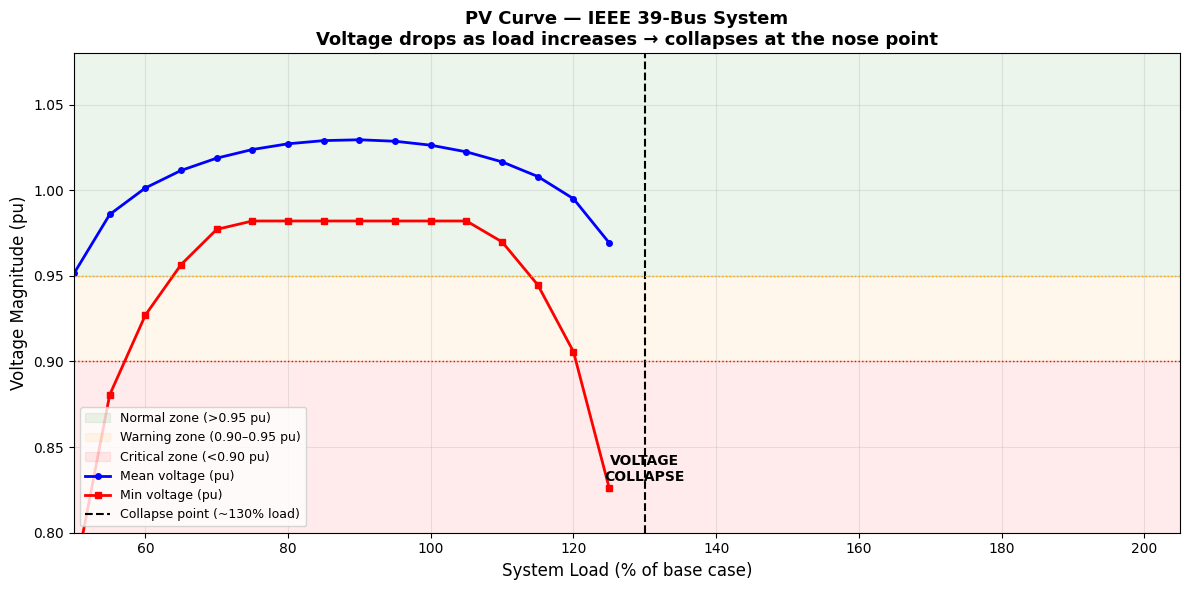

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

converged_df  = pv_df[pv_df['converged']]
collapsed_pct = pv_df[~pv_df['converged']]['load_pct'].min()

# Zones
ax.axhspan(0.95, 1.10, alpha=0.08, color='green',  label='Normal zone (>0.95 pu)')
ax.axhspan(0.90, 0.95, alpha=0.08, color='orange', label='Warning zone (0.90–0.95 pu)')
ax.axhspan(0.80, 0.90, alpha=0.08, color='red',    label='Critical zone (<0.90 pu)')

# PV curves
ax.plot(converged_df['load_pct'], converged_df['mean_voltage'],
        'b-o', linewidth=2, markersize=4, label='Mean voltage (pu)')
ax.plot(converged_df['load_pct'], converged_df['min_voltage'],
        'r-s', linewidth=2, markersize=4, label='Min voltage (pu)')

# Collapse point
if not np.isnan(collapsed_pct):
    ax.axvline(x=collapsed_pct, color='black', linestyle='--', linewidth=1.5,
               label=f'Collapse point (~{collapsed_pct:.0f}% load)')
    ax.annotate('VOLTAGE\nCOLLAPSE', xy=(collapsed_pct, 0.83),
                fontsize=10, color='black', fontweight='bold', ha='center')

# Limits
ax.axhline(y=0.95, color='orange', linestyle=':', linewidth=1)
ax.axhline(y=0.90, color='red',    linestyle=':', linewidth=1)

ax.set_xlabel('System Load (% of base case)', fontsize=12)
ax.set_ylabel('Voltage Magnitude (pu)', fontsize=12)
ax.set_title('PV Curve — IEEE 39-Bus System\nVoltage drops as load increases → collapses at the nose point',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.80, 1.08)
ax.set_xlim(50, pv_df['load_pct'].max() + 5)
ax.legend(fontsize=9, loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pv_curve_ieee39.png', dpi=150, bbox_inches='tight')
plt.show()